# Option Vega-Neutral Pair Trading Walkthrough
This notebook mirrors the equity pairs workflow but swaps in options and vega-balanced sizing using the utilities in `src/options/`. Use it as a living playbook: explore candidates, price contracts, run a backtest, then wire signals into the multi-leg executor.

## 1. Prerequisites
- Python 3.10+ virtualenv activated
- `pip install -r ../requirements.txt` (ensures `alpaca-py`, `py_vollib_vectorized`, `scipy`)
- `.env` with Alpaca Paper API keys if you want live data; otherwise the notebook falls back to synthetic fixtures so it can run offline.

In [ ]:
# Standard libraries
import json
import math
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

from src.options.data_handler import OptionDataHandler
from src.options.multileg import MultiLegExecutionHelper
from src.strategies.option_pairs import OptionPairsStrategy

pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8")
np.random.seed(42)
DATA_DIR = Path("../data")
PAIRS_PATH = DATA_DIR / "cointegrated_pairs.csv"

## 2. Pick a cointegrated pair
Load the CSV generated by the `0_find_pairs.ipynb` notebook (or drop in your own symbol list). We'll default to `MSFT`/`AAPL` if the file is missing.

In [ ]:
DEFAULT_PAIR = ("MSFT", "AAPL")
if PAIRS_PATH.exists():
    pairs_df = pd.read_csv(PAIRS_PATH)
    display(pairs_df.head())
    symbol_a = str(pairs_df.iloc[0]["symbol_a"]).upper()
    symbol_b = str(pairs_df.iloc[0]["symbol_b"]).upper()
else:
    print("Cointegration file not found; falling back to default pair", DEFAULT_PAIR)
    symbol_a, symbol_b = DEFAULT_PAIR

print(f"Using pair: {symbol_a} vs {symbol_b}")

,symbol_a,symbol_b,hedge_ratio,p_value
0,BLK,USB,9.070770,0.027424
1,SPGI,MCO,1.102522,0.023248
2,MCO,V,1.659694,0.039320
3,V,MA,0.527159,0.008333


Using pair: BLK vs USB


## 3. Build a data handler (offline-friendly)
`OptionPairsStrategy` expects the same `DataHandler` interface used by equities. To keep the notebook runnable without hitting Alpaca, we'll create a synthetic handler that mimics `get_historical_bars`/`get_latest_bar` and optionally swap in the real one if your API keys are available.

In [ ]:
DATES = pd.date_range(end=pd.Timestamp.today().normalize(), periods=240, freq="B")
base = np.linspace(90, 130, len(DATES))
noise_a = np.random.normal(scale=1.5, size=len(DATES))
noise_b = np.random.normal(scale=1.0, size=len(DATES))
prices_a = base + noise_a
prices_b = base * 0.92 + noise_b

synthetic_frames = {
    symbol_a: pd.DataFrame({"close": prices_a}, index=DATES),
    symbol_b: pd.DataFrame({"close": prices_b}, index=DATES),
}

@dataclass
class NotebookDataHandler:
    use_alpaca: bool = bool(os.environ.get("APCA_API_KEY_ID"))

    def __post_init__(self):
        self.real_handler = None
        if self.use_alpaca:
            from src.data_handler import DataHandler
            self.real_handler = DataHandler()

    def get_historical_bars(self, symbols, timeframe, start, end=None):
        if self.real_handler:
            return self.real_handler.get_historical_bars(symbols, timeframe, start, end)
        return {sym: synthetic_frames[sym] for sym in symbols}

    def get_latest_bar(self, symbol):
        if self.real_handler:
            return self.real_handler.get_latest_bar(symbol)
        df = synthetic_frames[symbol]
        return {"close": float(df.iloc[-1]["close"])}

data_handler = NotebookDataHandler()
print(f"Using {'Alpaca' if data_handler.use_alpaca else 'synthetic'} data handler")

Data Handler (alpaca-py) initialized.
Using Alpaca data handler


## 4. Option snapshot & greeks
`OptionDataHandler` wraps our data source and combines it with the `GreeksCalculator` so we can request the contract closest to a target delta. We'll inspect both legs, then size the hedge by vega.

In [ ]:
option_data = OptionDataHandler(data_handler)

snapshot_a = option_data.get_option_snapshot(
    symbol=symbol_a,
    option_type="call",
    target_delta=0.45,
    days_to_expiry=30,
)
snapshot_b = option_data.get_option_snapshot(
    symbol=symbol_b,
    option_type="call",
    target_delta=0.45,
    days_to_expiry=30,
)

print("Leg A snapshot:")
display(snapshot_a)
print("\nLeg B snapshot:")
display(snapshot_b)
print(f"Vega ratio (A/B): {option_data.greeks.metrics('call', snapshot_a.spot, snapshot_a.strike, snapshot_a.ttm, snapshot_a.implied_vol)['vega'] / max(snapshot_b.vega, 1e-6):.2f}")

Submitting data request to Alpaca...
Submitting data request to Alpaca...
Leg A snapshot:
Submitting data request to Alpaca...
Leg A snapshot:


OptionSnapshot(symbol='BLK', option_type='call', strike=1032.6138222961426, expiration='2025-12-18', ttm=0.11904761904761904, spot=1020.01, implied_vol=0.20051742994422925, price=22.979592989050047, delta=0.4499817345634444, vega=139.2975283024538, gamma=0.0056086935020602776, theta=-121.67270872655467)


Leg B snapshot:


OptionSnapshot(symbol='USB', option_type='call', strike=45.773556976318346, expiration='2025-12-18', ttm=0.11904761904761904, spot=45.3, implied_vol=0.1718566639056424, price=0.8798079552892446, delta=0.45000133279175997, vega=6.1864268993505425, gamma=0.14735212069102824, theta=-4.660403015559523)

Vega ratio (A/B): 22.52


## 5. Configure `OptionPairsStrategy` and run a backtest
We'll reuse the synthetic history for both legs. Feel free to plug in real Alpaca data (set `APCA_API_KEY_ID`/`APCA_API_SECRET_KEY` in `.env`) and tighten the thresholds once you're confident.

In [ ]:
strategy = OptionPairsStrategy(
    data_handler=data_handler,
    execution_handler=None,
    symbol_a=symbol_a,
    symbol_b=symbol_b,
    option_type="call",
    target_delta=0.45,
    days_to_expiry=30,
    entry_threshold=0.5,
    exit_threshold=0.0,
    contracts=1,
    lookback_days=60,
    timeframe="1H",
    auto_execute=False,
    option_data_handler=option_data,
)

summary = strategy.run_backtest(
    start_date=(DATES[0]).date().isoformat(),
    end_date=(DATES[-1]).date().isoformat(),
    timeframe="1D",
)
summary

BaseStrategy initialized with symbols: ['BLK', 'USB']
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...


{'num_trades': 11,
 'open_trades': 1,
 'total_pnl': np.float64(98.28708656557865),
 'win_rate': 0.7272727272727273,
 'strategy_return': np.float64(0.009828708656557827),
 'sharpe': 1.571150621670814,
 'max_drawdown': 0.001959627717000312,
 'equity_curve': timestamp
 2025-01-22 05:00:00    10000.000000
 2025-01-23 05:00:00    10000.000000
 2025-01-24 05:00:00    10000.000000
 2025-01-27 05:00:00    10000.000000
 2025-01-28 05:00:00    10059.045873
                            ...     
 2025-11-11 05:00:00    10098.287087
 2025-11-12 05:00:00    10098.287087
 2025-11-13 05:00:00    10098.287087
 2025-11-14 05:00:00    10098.287087
 2025-11-17 05:00:00    10098.287087
 Length: 208, dtype: float64,
 'trades': [{'timestamp': '2025-01-27 05:00:00',
   'direction': 'long',
   'entry_a': np.float64(25.933302453201634),
   'entry_b': np.float64(3.780646672136996),
   'vega_ratio': np.float64(49.6515593900471),
   'exit_a': np.float64(37.481640781000806),
   'exit_b': np.float64(2.824029485587921

Submitting data request to Alpaca...


strategy_return       0.98%
benchmark_return      9.77%
excess_return        -8.78%
sharpe              157.12%
max_drawdown          0.20%
dtype: object

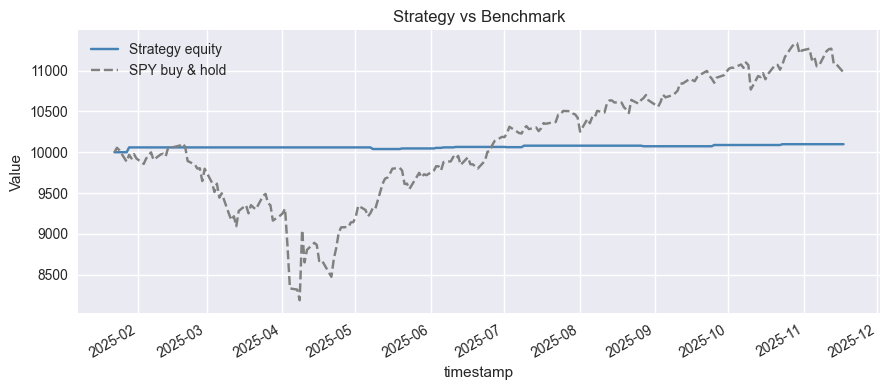

In [ ]:
# Benchmark comparison (run after the backtest cell)
BENCHMARK_SYMBOL = "SPY"
benchmark_data = data_handler.get_historical_bars(
    [BENCHMARK_SYMBOL],
    "1D",
    start=(DATES[0]).date().isoformat(),
    end=(DATES[-1]).date().isoformat(),
)

bench_df = (benchmark_data or {}).get(BENCHMARK_SYMBOL)
if bench_df is None or bench_df.empty:
    print(f"No benchmark data for {BENCHMARK_SYMBOL}; skipping comparison.")
else:
    bench_series = bench_df["close"].astype(float)
    bench_series.index = pd.to_datetime(bench_series.index).tz_localize(None)
    bench_series = bench_series.sort_index()
    bench_series = bench_series.loc[
        (bench_series.index >= summary["equity_curve"].index[0])
        & (bench_series.index <= summary["equity_curve"].index[-1])
    ]
    benchmark_return = float(bench_series.iloc[-1] / bench_series.iloc[0] - 1)
    summary["benchmark_return"] = benchmark_return
    summary["excess_return"] = summary["strategy_return"] - benchmark_return
    display(
        pd.Series(
            {
                "strategy_return": summary["strategy_return"],
                "benchmark_return": benchmark_return,
                "excess_return": summary["excess_return"],
                "sharpe": summary["sharpe"],
                "max_drawdown": summary["max_drawdown"],
            }
        ).apply(lambda x: f"{x:.2%}" if isinstance(x, float) else x)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    summary["equity_curve"].plot(ax=ax, label="Strategy equity", color="steelblue")
    bench_equity = bench_series / bench_series.iloc[0] * summary["equity_curve"].iloc[0]
    bench_equity.plot(ax=ax, label=f"{BENCHMARK_SYMBOL} buy & hold", color="gray", linestyle="--")
    ax.set_title("Strategy vs Benchmark")
    ax.set_ylabel("Value")
    ax.legend()
    plt.tight_layout()

### Plot equity curve and z-score drift
Quick visualization to confirm the synthetic spread behaves as expected. When you swap in Alpaca data this chart updates automatically.

Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...
Submitting data request to Alpaca...


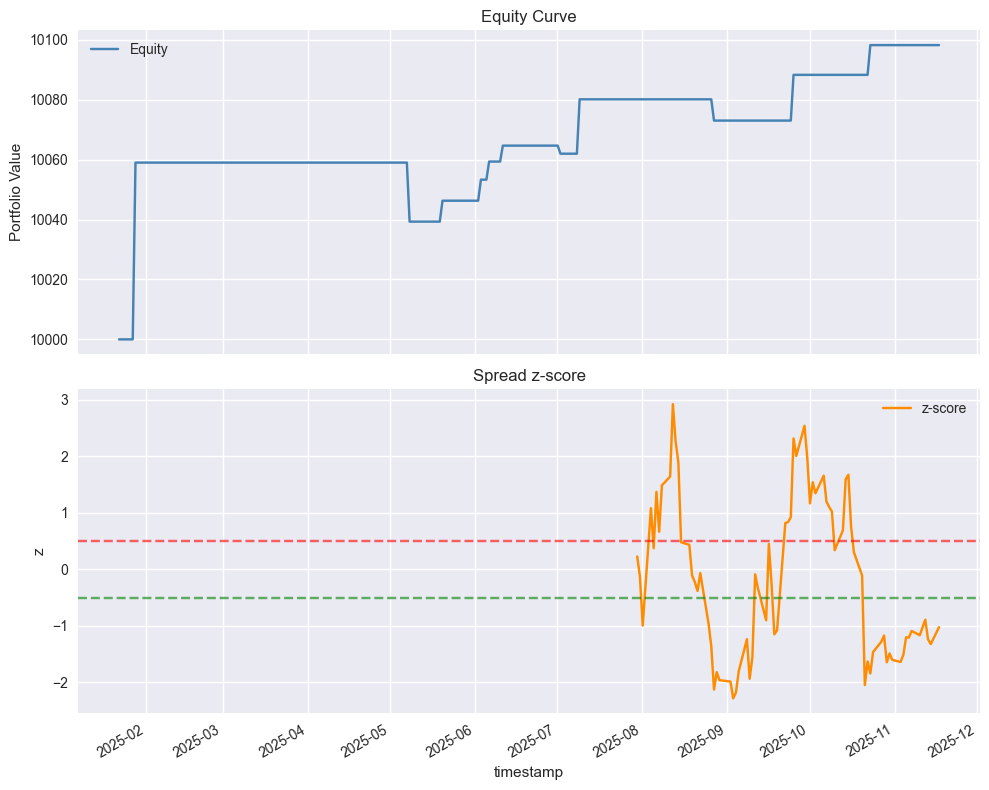

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
summary["equity_curve"].plot(ax=axes[0], color="steelblue", label="Equity")
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Portfolio Value")
axes[0].legend()

spread_df = strategy._build_option_series(
    start=strategy._iso_days_ago(strategy.lookback_days),
    end=strategy._iso_days_ago(0),
    timeframe=strategy.timeframe,
)
spread_df["z_score"].plot(ax=axes[1], color="darkorange", label="z-score")
axes[1].axhline(strategy.entry_threshold, color="red", linestyle="--", alpha=0.6)
axes[1].axhline(-strategy.entry_threshold, color="green", linestyle="--", alpha=0.6)
axes[1].set_title("Spread z-score")
axes[1].set_ylabel("z")
axes[1].legend()
plt.tight_layout()

## 6. Generate live-ready signals
Hook the strategy into the multi-leg execution helper. When `auto_execute=True`, each signal becomes a debit/credit payload. Here we keep it manual so you can inspect the legs first.

In [ ]:
multi_leg = MultiLegExecutionHelper(execution_handler=None)
strategy.auto_execute = False
signals = strategy.generate_signal()
print("Generated signals:")
for leg in signals:
    print(leg)

payload = multi_leg.build_payload(signals, net_price_type="debit")
print("\nPayload ready for execution handler:")
print(json.dumps(payload, indent=2))

Submitting data request to Alpaca...
Submitting data request to Alpaca...
Generated signals:
{'asset_type': 'option', 'underlying': 'BLK', 'symbol': 'BLK', 'option_type': 'call', 'strike': 1032.6138222961426, 'expiration': '2025-12-18', 'action': 'buy', 'qty': 1, 'limit_price': 22.979592989050047, 'type': 'limit', 'time_in_force': 'day'}
{'asset_type': 'option', 'underlying': 'USB', 'symbol': 'USB', 'option_type': 'call', 'strike': 45.773556976318346, 'expiration': '2025-12-18', 'action': 'sell', 'qty': 23, 'limit_price': 0.8798079552892446, 'type': 'limit', 'time_in_force': 'day'}

Payload ready for execution handler:
{
  "legs": [
    {
      "action": "buy",
      "qty": 1,
      "asset_type": "option",
      "time_in_force": "day",
      "order_type": "limit",
      "limit_price": 22.979592989050047,
      "underlying": "BLK",
      "symbol": "BLK",
      "option_type": "call",
      "strike": 1032.6138222961426,
      "expiration": "2025-12-18",
      "type": "limit"
    },
    {


## 7. Next steps
1. Flip `NotebookDataHandler(use_alpaca=True)` by exporting Alpaca keys in `.env` to stream real quotes.\n2. Schedule the backtest to refresh candidate pairs nightly and log performance deltas.\n3. When comfortable, set `strategy.auto_execute = True` *after* swapping `execution_handler` for the real `ExecutionHandler` so signals route to Alpaca.